In [13]:
!pip install ultralytics

In [1]:
from huggingface_hub import login
login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="RahulAloth/crf-dataset", repo_type="dataset")
dataset_path

Fetching 139 files:   0%|          | 0/139 [00:00<?, ?it/s]

'/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

Please check the repository on Hugging Face: [https://huggingface.co/RahulAloth/crf-dataset](https://huggingface.co/RahulAloth/crf-dataset)

In [3]:
import os

dataset_abs_path = '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

print(f"Listing contents of the root dataset directory: {dataset_abs_path}/")
!ls -F {dataset_abs_path}/

Listing contents of the root dataset directory: /root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475/
crf_train/  crf_val/  README.md@


In [4]:
import os

dataset_abs_path = '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

print(f"Listing contents of {dataset_abs_path}/crf_train/ recursively:")
!ls -R {dataset_abs_path}/crf_train/

print(f"\nListing contents of {dataset_abs_path}/crf_val/ recursively:")
!ls -R {dataset_abs_path}/crf_val/

Listing contents of /root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475/crf_train/ recursively:
/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475/crf_train/:
images	labels	train.json

/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475/crf_train/images:
CRF_Annotation10.png		 crf_cardiovascular_page_018.png
CRF_Annotation11.png		 crf_cardiovascular_page_019.png
CRF_Annotation12.png		 crf_cardiovascular_page_020.png
CRF_Annotation13.png		 crf_glaucoma_page_001.png
CRF_Annotation14.png		 crf_glaucoma_page_003.png
CRF_Annotation15.png		 crf_glaucoma_page_004.png
CRF_Annotation16.png		 crf_glaucoma_page_005.png
CRF_Annotation17.png		 crf_glaucoma_page_006.png
CRF_Annotation18.png		 crf_glaucoma_page_008.png
CRF_Annotation19.png		 crf_glaucoma_page_009.png
CRF_Annotation1.png		 crf_glaucoma_page_010.png
CR

In [6]:
import json
import os

dataset_abs_path = '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

# Path to the train.json file
train_json_path = os.path.join(dataset_abs_path, 'crf_train', 'train.json')

print(f"Reading contents of: {train_json_path}")

# Read and display the first few lines or a sample of the JSON file
try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
    print("Successfully loaded train.json.")
    # Print a summary or the first few items to understand its structure
    if isinstance(train_data, list) and len(train_data) > 0:
        print(f"Number of entries in train.json: {len(train_data)}")
        print("First entry sample:")
        print(json.dumps(train_data[0], indent=2))
    elif isinstance(train_data, dict):
        print(f"Keys in train.json: {train_data.keys()}")
        # If it's a dict, maybe it has a 'data' key or similar
        if 'annotations' in train_data and isinstance(train_data['annotations'], list):
            print(f"Number of annotations: {len(train_data['annotations'])}")
            if len(train_data['annotations']) > 0:
                print("First annotation sample:")
                print(json.dumps(train_data['annotations'][0], indent=2))
        else:
            # Print entire dict if small, or a subset
            print(json.dumps(train_data, indent=2))
    else:
        print("Unknown JSON structure.")
except FileNotFoundError:
    print(f"Error: {train_json_path} not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Reading contents of: /root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475/crf_train/train.json
Successfully loaded train.json.
Keys in train.json: dict_keys(['images', 'annotations', 'categories'])
Number of annotations: 1375
First annotation sample:
{
  "id": 1,
  "image_id": 1,
  "category_id": 2,
  "segmentation": [],
  "area": 3922.876800000001,
  "bbox": [
    250.06,
    284.43,
    114.57,
    34.24
  ],
  "iscrowd": 0,
  "attributes": {
    "occluded": false,
    "rotation": 0.0
  }
}


In [9]:
import json
import os
from PIL import Image

# Ensure this path explicitly points to the new, reliable dataset location
dataset_abs_path = '/content/crf-dataset-fresh'

def convert_coco_to_yolo(split):
    print(f"\nConverting {split} annotations from COCO to YOLO format...")
    json_path = os.path.join(dataset_abs_path, f'crf_{split}', f'{split}.json')
    images_dir = os.path.join(dataset_abs_path, f'crf_{split}', 'images')
    labels_dir = os.path.join(dataset_abs_path, f'crf_{split}', 'labels')

    os.makedirs(labels_dir, exist_ok=True)

    with open(json_path, 'r') as f:
        data = json.load(f)

    images_metadata = {img['id']: {'file_name': img['file_name'], 'width': img['width'], 'height': img['height']} for img in data['images']}
    categories = {cat['id']: cat['name'] for cat in data['categories']}

    # The category IDs in the dataset are 1-indexed. YOLO expects 0-indexed.
    # We need to map them to 0 and 1, based on the `data.yaml` names.
    # From inspection of previous output, category ID 1 is 'section_header' and ID 2 is 'sdtm_box'.
    # We will map 'section_header' to YOLO class 0 (header) and 'sdtm_box' to YOLO class 1 (field).
    class_mapping = {
        # Map original category ID to YOLO class ID
        1: 0, # 'section_header' -> header (class 0)
        2: 1  # 'sdtm_box' -> field (class 1)
    }

    for ann in data['annotations']:
        image_id = ann['image_id']
        category_id = ann['category_id']

        if image_id not in images_metadata:
            print(f"Warning: Image ID {image_id} not found in metadata. Skipping annotation.")
            continue

        if category_id not in class_mapping:
            # This warning should ideally not appear now if all relevant categories are mapped
            print(f"Warning: Category ID {category_id} not mapped to a YOLO class. Skipping annotation.")
            continue

        img_meta = images_metadata[image_id]
        img_width = img_meta['width']
        img_height = img_meta['height']
        img_file_name = img_meta['file_name']

        # COCO bbox: [x_top_left, y_top_left, width, height]
        # YOLO bbox: [class_id x_center y_center width height] (normalized)
        x_tl, y_tl, bbox_width, bbox_height = ann['bbox']

        # Calculate center coordinates
        x_center = (x_tl + bbox_width / 2) / img_width
        y_center = (y_tl + bbox_height / 2) / img_height

        # Normalize width and height
        normalized_width = bbox_width / img_width
        normalized_height = bbox_height / img_height

        # Get YOLO class ID
        yolo_class_id = class_mapping[category_id]

        label_file_name = os.path.splitext(img_file_name)[0] + '.txt'
        label_file_path = os.path.join(labels_dir, label_file_name)

        # Append to file as there might be multiple annotations per image
        with open(label_file_path, 'a') as f:
            f.write(f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {normalized_width:.6f} {normalized_height:.6f}\n")

    print(f"Conversion complete for {split} split. Labels saved to {labels_dir}")

# Run conversion for both train and val splits
convert_coco_to_yolo('train')
convert_coco_to_yolo('val')

print("\nVerifying created label files...")
# Verify by listing some created label files
print(f"Listing first 5 label files in {os.path.join(dataset_abs_path, 'crf_train', 'labels')}:")
!ls {os.path.join(dataset_abs_path, 'crf_train', 'labels')} | head -n 5
print(f"Listing first 5 label files in {os.path.join(dataset_abs_path, 'crf_val', 'labels')}:")
!ls {os.path.join(dataset_abs_path, 'crf_val', 'labels')} | head -n 5

# Also inspect the first created label file to check content
train_labels_path = os.path.join(dataset_abs_path, 'crf_train', 'labels')
first_train_label_file = next(iter(os.listdir(train_labels_path)), None)
if first_train_label_file:
    print(f"\nContent of first train label file ({first_train_label_file}):")
    with open(os.path.join(train_labels_path, first_train_label_file), 'r') as f:
        print(f.read())
else:
    print("No label files found in train set.")


Converting train annotations from COCO to YOLO format...
Conversion complete for train split. Labels saved to /content/crf-dataset-fresh/crf_train/labels

Converting val annotations from COCO to YOLO format...
Conversion complete for val split. Labels saved to /content/crf-dataset-fresh/crf_val/labels

Verifying created label files...
Listing first 5 label files in /content/crf-dataset-fresh/crf_train/labels:
CRF_Annotation10.txt
CRF_Annotation11.txt
CRF_Annotation12.txt
CRF_Annotation13.txt
CRF_Annotation14.txt
Listing first 5 label files in /content/crf-dataset-fresh/crf_val/labels:
crf_cardiovascular_page_002.txt
crf_cardiovascular_page_007.txt
crf_glaucoma_page_007.txt
crf_image_12.txt
crf_image_13.txt

Content of first train label file (CRF_Annotation12.txt):
1 0.764559 0.410704 0.122941 0.018375
1 0.644281 0.197431 0.078399 0.027593
1 0.741389 0.240102 0.094444 0.026245
1 0.481225 0.300481 0.112255 0.023586
1 0.119493 0.297190 0.201373 0.017052
1 0.699518 0.298502 0.121160 0.019

In [8]:
import os
from ultralytics import YOLO
from huggingface_hub import snapshot_download
import shutil

# --- Step 1: Re-download the dataset to a predictable location in /content/ ---
# This ensures the dataset is accessible within the current runtime,
# bypassing potential issues with the HuggingFace cache directory's path resolution.
print("Re-downloading dataset to /content/crf-dataset-fresh for reliable access...")
downloaded_cache_path = snapshot_download(repo_id="RahulAloth/crf-dataset", repo_type="dataset")

new_dataset_base_path = '/content/crf-dataset-fresh'
# Clean up previous attempts if any
if os.path.exists(new_dataset_base_path):
    print(f"Removing existing directory: {new_dataset_base_path}")
    shutil.rmtree(new_dataset_base_path)
# Copy the entire downloaded content from the cache to the new reliable location
print(f"Copying dataset from cache '{downloaded_cache_path}' to '{new_dataset_base_path}'")
shutil.copytree(downloaded_cache_path, new_dataset_base_path)
print(f"Dataset successfully moved from cache to: {new_dataset_base_path}")

# --- Step 2: Define paths based on the new reliable location ---
# Now use new_dataset_base_path as the base for all dataset operations.
# These are the parent directories that will contain 'images' and 'labels' subdirectories.
train_dir_for_yaml = os.path.join(new_dataset_base_path, 'crf_train')
val_dir_for_yaml = os.path.join(new_dataset_base_path, 'crf_val')

# --- Step 3: Ensure the labels are in YOLO format ---
# This part assumes the COCO to YOLO conversion script (from a previous cell) has been executed.
# If not, that cell needs to be run before this one to create the 'labels' directories and .txt files.
# We assume 'crf_train/labels' and 'crf_val/labels' are now populated with YOLO .txt files.

# Define the content of data.yaml
yaml_content_corrected = f"""
train: {train_dir_for_yaml}
val: {val_dir_for_yaml}

names:
  0: header
  1: field
"""

# Write the corrected content to data.yaml
yaml_file_path = "data.yaml"
with open(yaml_file_path, "w") as f:
    f.write(yaml_content_corrected)

print(f"Rewrote {yaml_file_path} at: {os.path.abspath(yaml_file_path)} with corrected paths: train={train_dir_for_yaml}, val={val_dir_for_yaml}")

# --- Step 4: Train the YOLO model ---
model = YOLO("yolov8n.pt")  # nano model for speed

print("\nStarting YOLOv8 model training...")
model.train(
    data="/content/data.yaml",  # Point to the newly created data.yaml
    epochs=50,
    imgsz=1024,
    batch=4,
    workers=2,
    device=0  # GPU
)

Re-downloading dataset to /content/crf-dataset-fresh for reliable access...


Fetching 139 files:   0%|          | 0/139 [00:00<?, ?it/s]

Removing existing directory: /content/crf-dataset-fresh
Copying dataset from cache '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475' to '/content/crf-dataset-fresh'
Dataset successfully moved from cache to: /content/crf-dataset-fresh
Rewrote data.yaml at: /content/data.yaml with corrected paths: train=/content/crf-dataset-fresh/crf_train, val=/content/crf-dataset-fresh/crf_val

Starting YOLOv8 model training...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epoc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3205745d60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

### Visualizing Training Results

Ultralytics automatically saves various plots during training, which provide insights into the model's performance and training progress. Let's display some of them.

Displaying key plots from: /content/runs/detect/train-8

--- Overall Training Results (Precision, Recall, mAP over epochs) ---


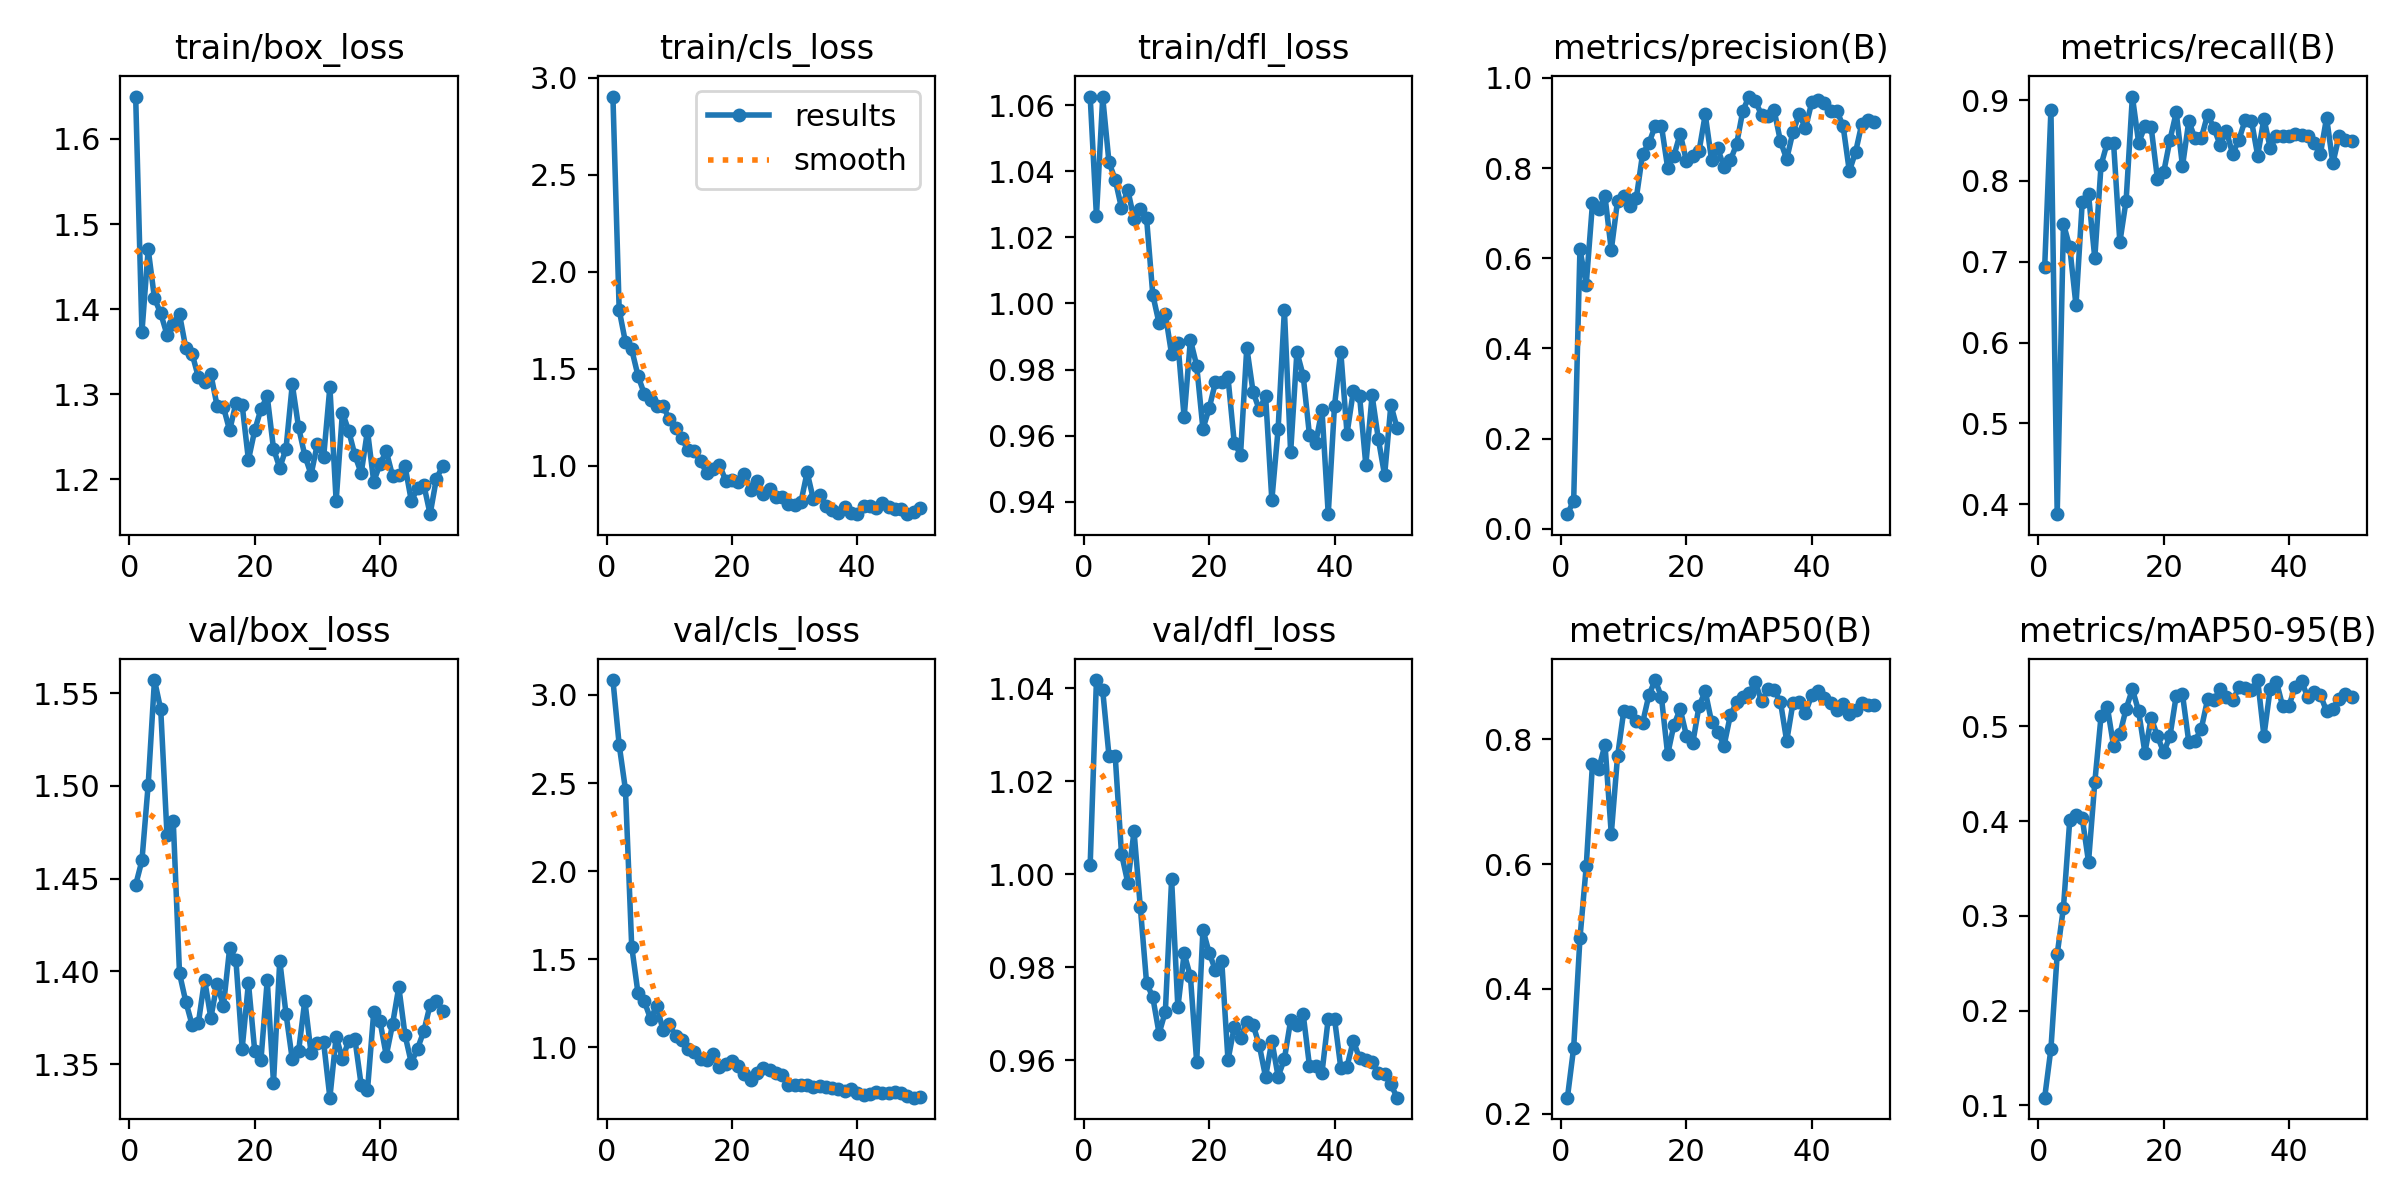

F1-Confidence curve not found at: /content/runs/detect/train-8/F1_curve.png
Precision-Confidence curve not found at: /content/runs/detect/train-8/P_curve.png
Recall-Confidence curve not found at: /content/runs/detect/train-8/R_curve.png

--- Confusion Matrix ---


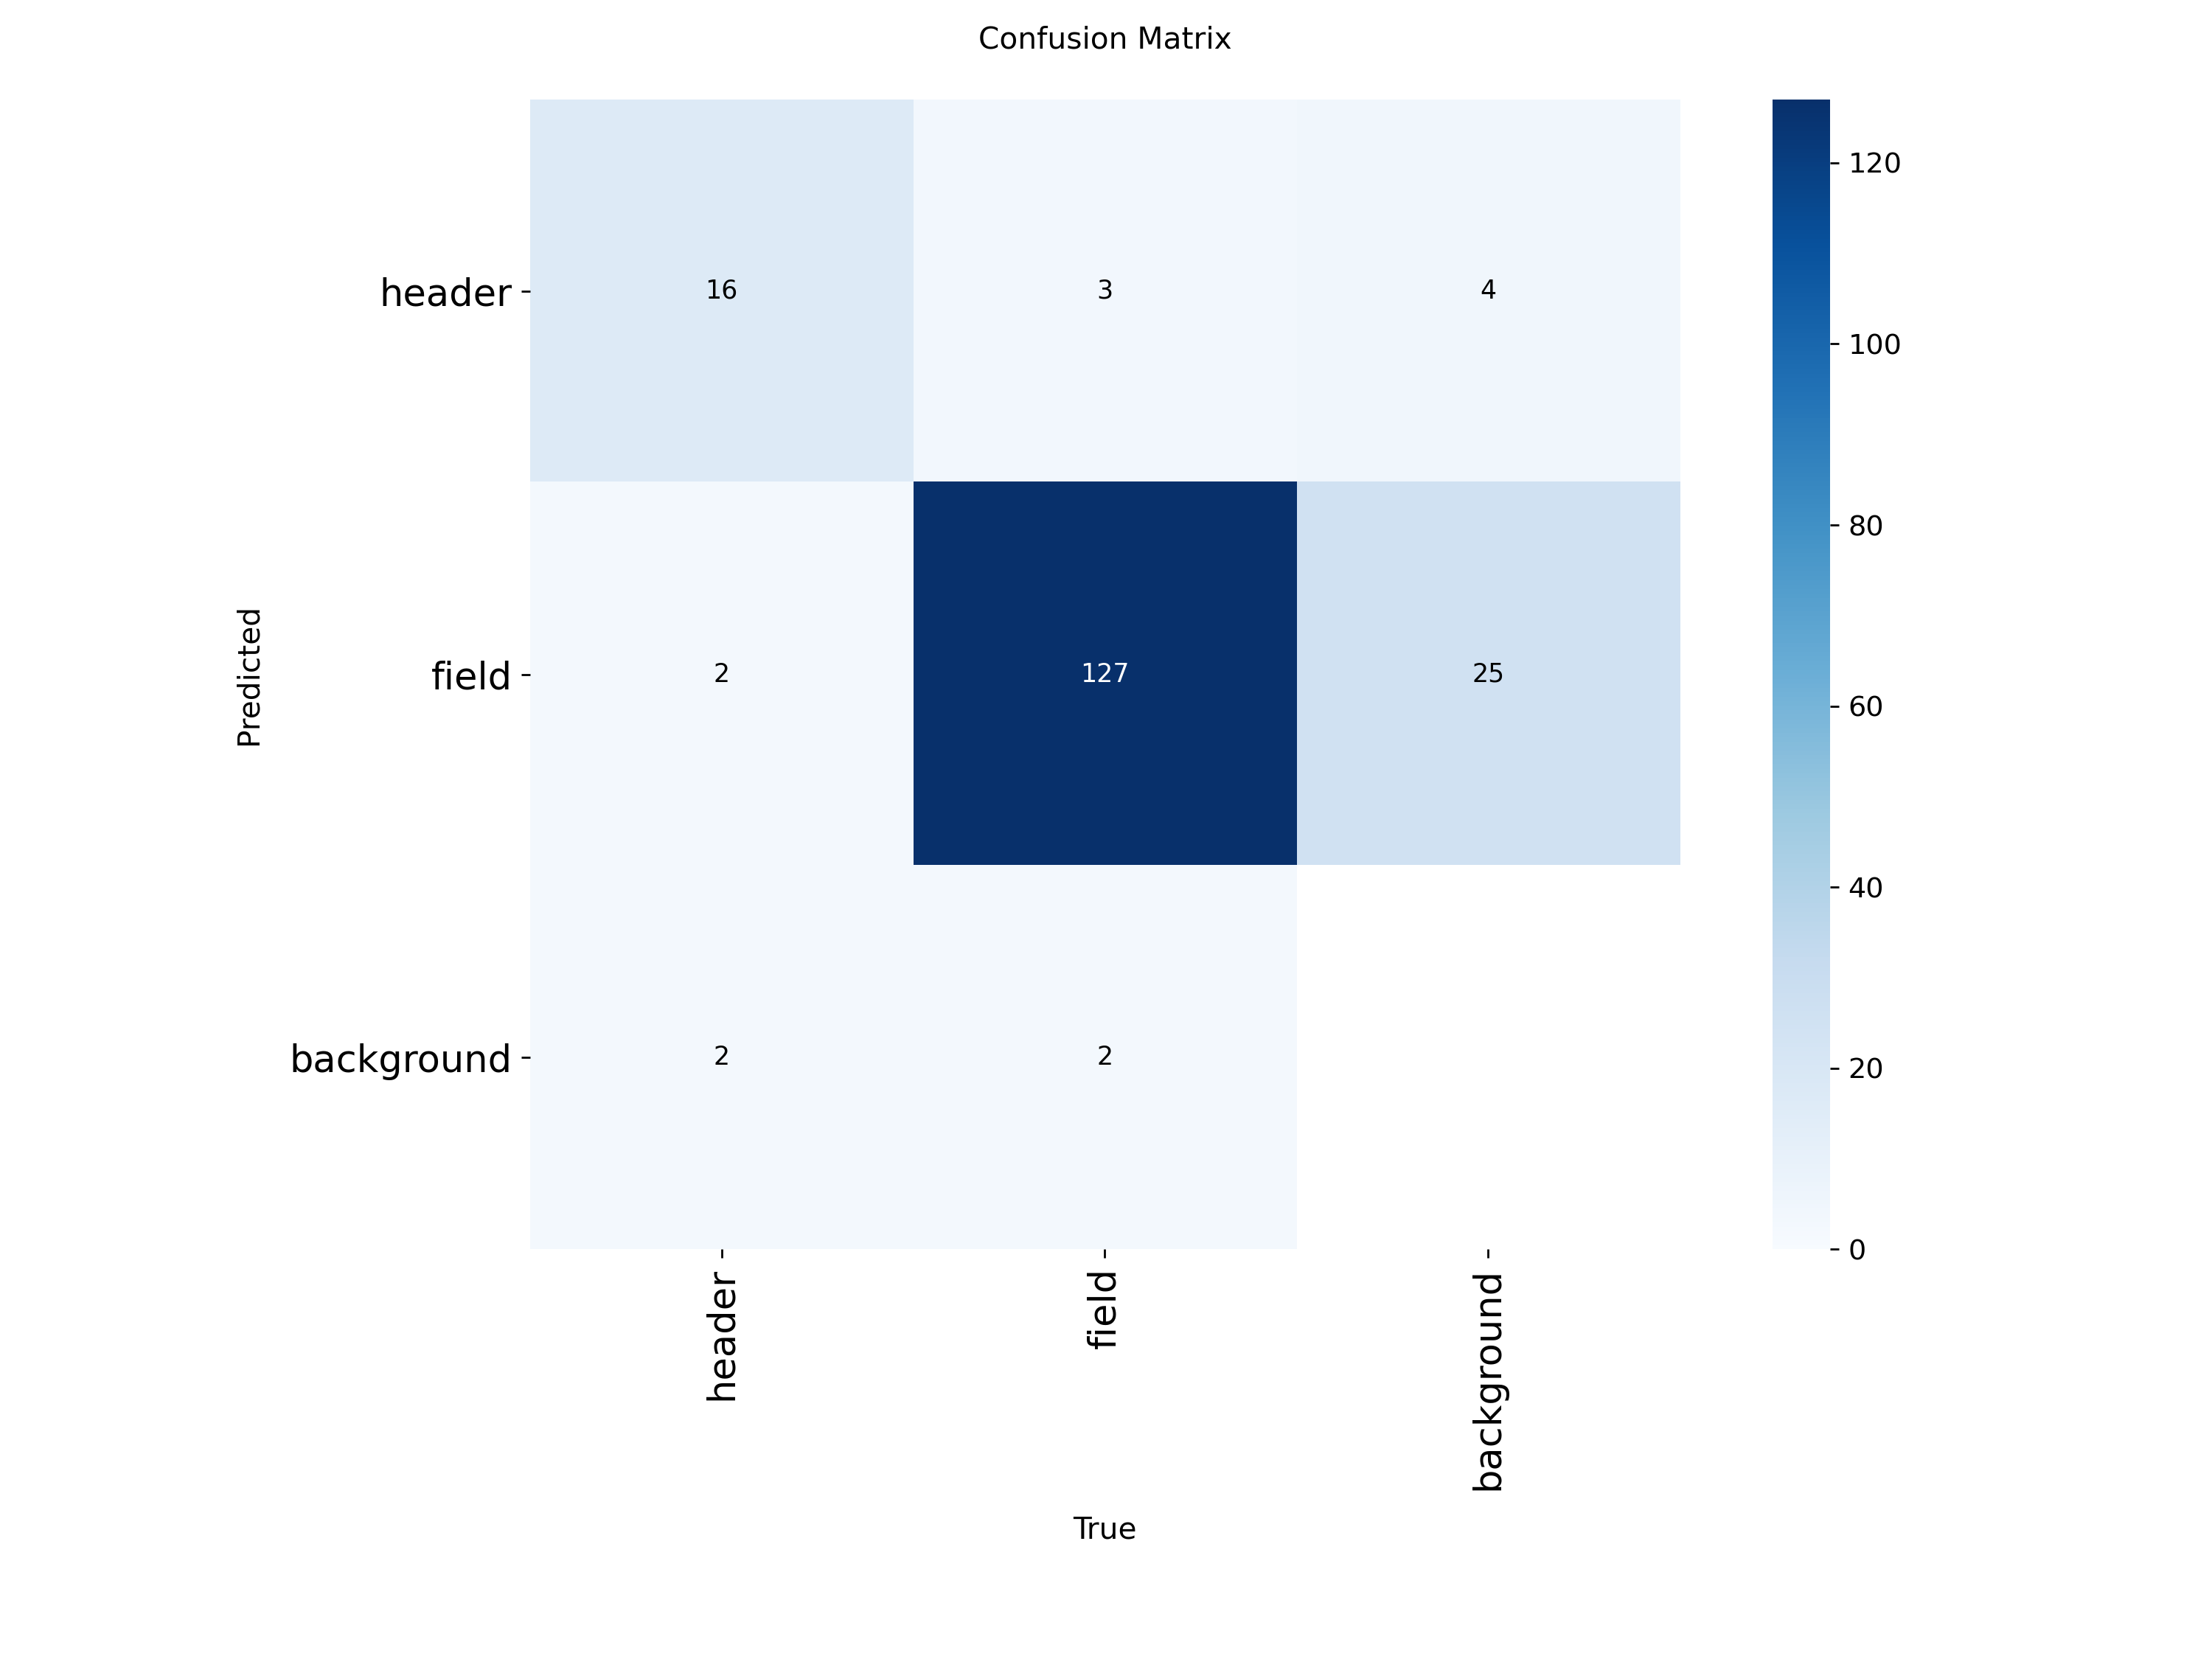


--- Example Validation Predictions ---


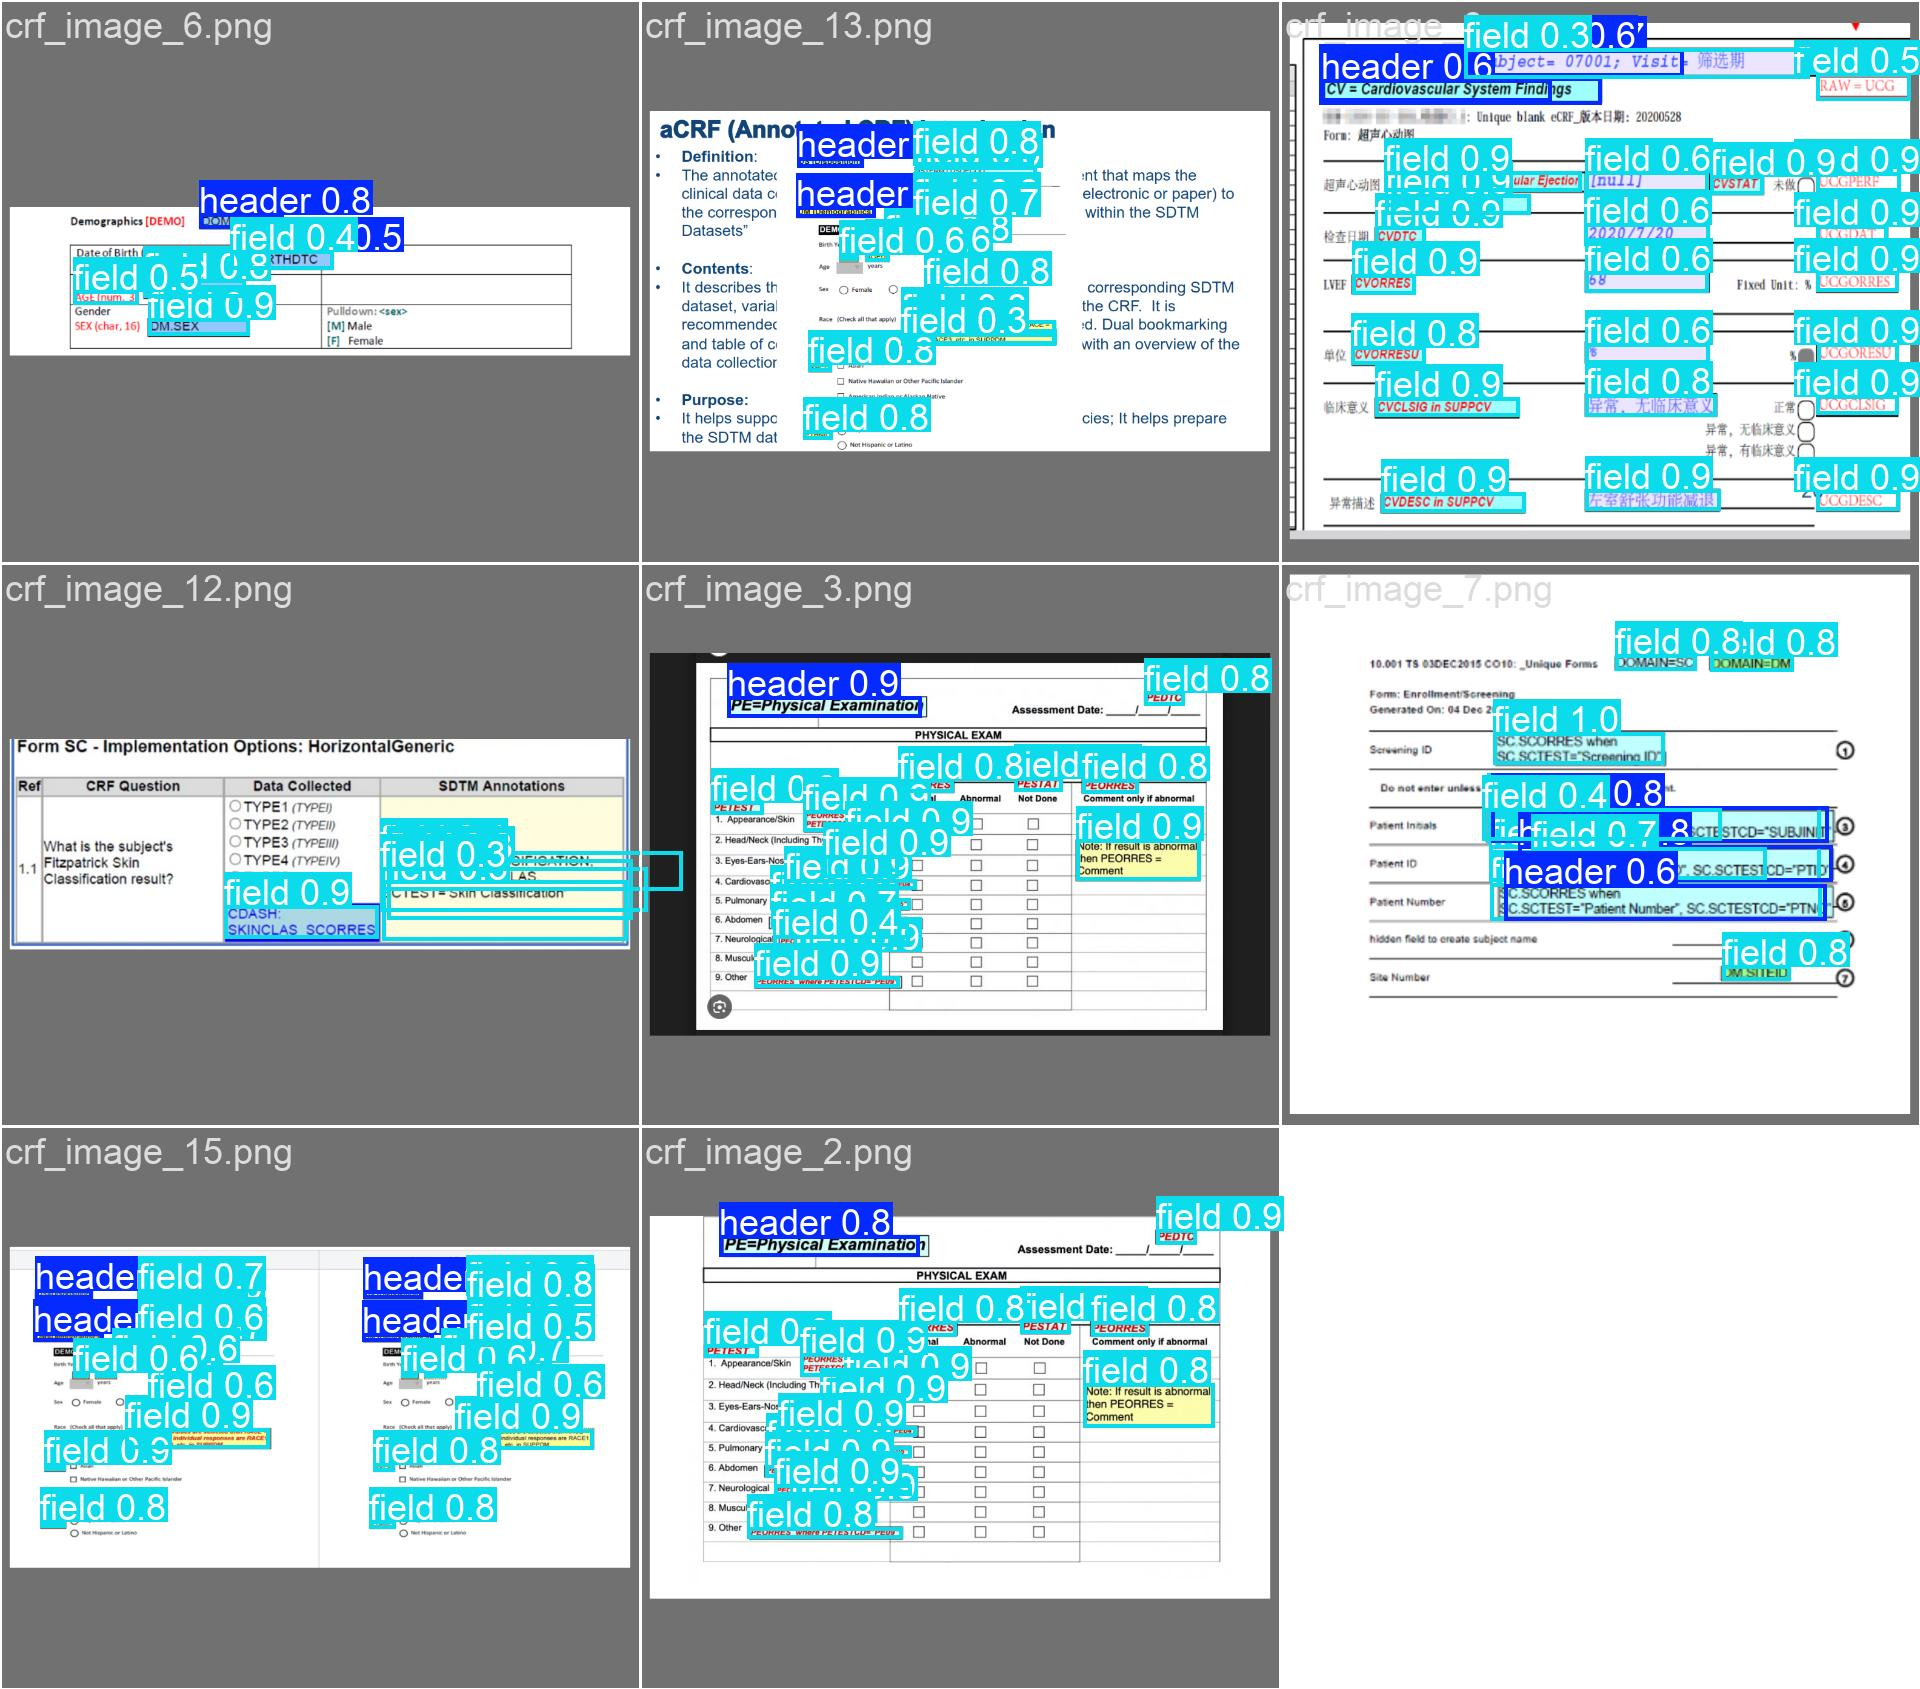

In [12]:
from IPython.display import Image, display
import os

# The training results are saved in the 'runs/detect/train-8' directory
results_dir = '/content/runs/detect/train-8'

print(f"Displaying key plots from: {results_dir}")

# Display the overall results plot
results_plot_path = os.path.join(results_dir, 'results.png')
if os.path.exists(results_plot_path):
    print("\n--- Overall Training Results (Precision, Recall, mAP over epochs) ---")
    display(Image(filename=results_plot_path))
else:
    print(f"Results plot not found at: {results_plot_path}")

# Display the F1-Confidence curve
f1_curve_path = os.path.join(results_dir, 'F1_curve.png')
if os.path.exists(f1_curve_path):
    print("\n--- F1-Confidence Curve ---")
    display(Image(filename=f1_curve_path))
else:
    print(f"F1-Confidence curve not found at: {f1_curve_path}")

# Display the P-Confidence curve
p_curve_path = os.path.join(results_dir, 'P_curve.png')
if os.path.exists(p_curve_path):
    print("\n--- Precision-Confidence Curve ---")
    display(Image(filename=p_curve_path))
else:
    print(f"Precision-Confidence curve not found at: {p_curve_path}")

# Display the R-Confidence curve
r_curve_path = os.path.join(results_dir, 'R_curve.png')
if os.path.exists(r_curve_path):
    print("\n--- Recall-Confidence Curve ---")
    display(Image(filename=r_curve_path))
else:
    print(f"Recall-Confidence curve not found at: {r_curve_path}")

# Display the confusion matrix
confusion_matrix_path = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("\n--- Confusion Matrix ---")
    display(Image(filename=confusion_matrix_path))
else:
    print(f"Confusion matrix not found at: {confusion_matrix_path}")

# Display an example validation batch with predictions
val_pred_image_path = os.path.join(results_dir, 'val_batch0_pred.jpg')
if os.path.exists(val_pred_image_path):
    print("\n--- Example Validation Predictions ---")
    display(Image(filename=val_pred_image_path))
else:
    print(f"Example validation prediction image not found at: {val_pred_image_path}")

### Run Inference on a New Image

Now that we have a trained model, let's use it to make predictions on an unseen image from our validation set.

Loaded model from: /content/runs/detect/train-8/weights/best.pt
Running inference on sample image: /content/crf-dataset-fresh/crf_val/images/crf_cardiovascular_page_007.png

image 1/1 /content/crf-dataset-fresh/crf_val/images/crf_cardiovascular_page_007.png: 1024x736 1 header, 6 fields, 42.0ms
Speed: 6.0ms preprocess, 42.0ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 736)
Results saved to /content/runs/detect/predict_sample_2

--- Inference Results on crf_cardiovascular_page_007.png ---


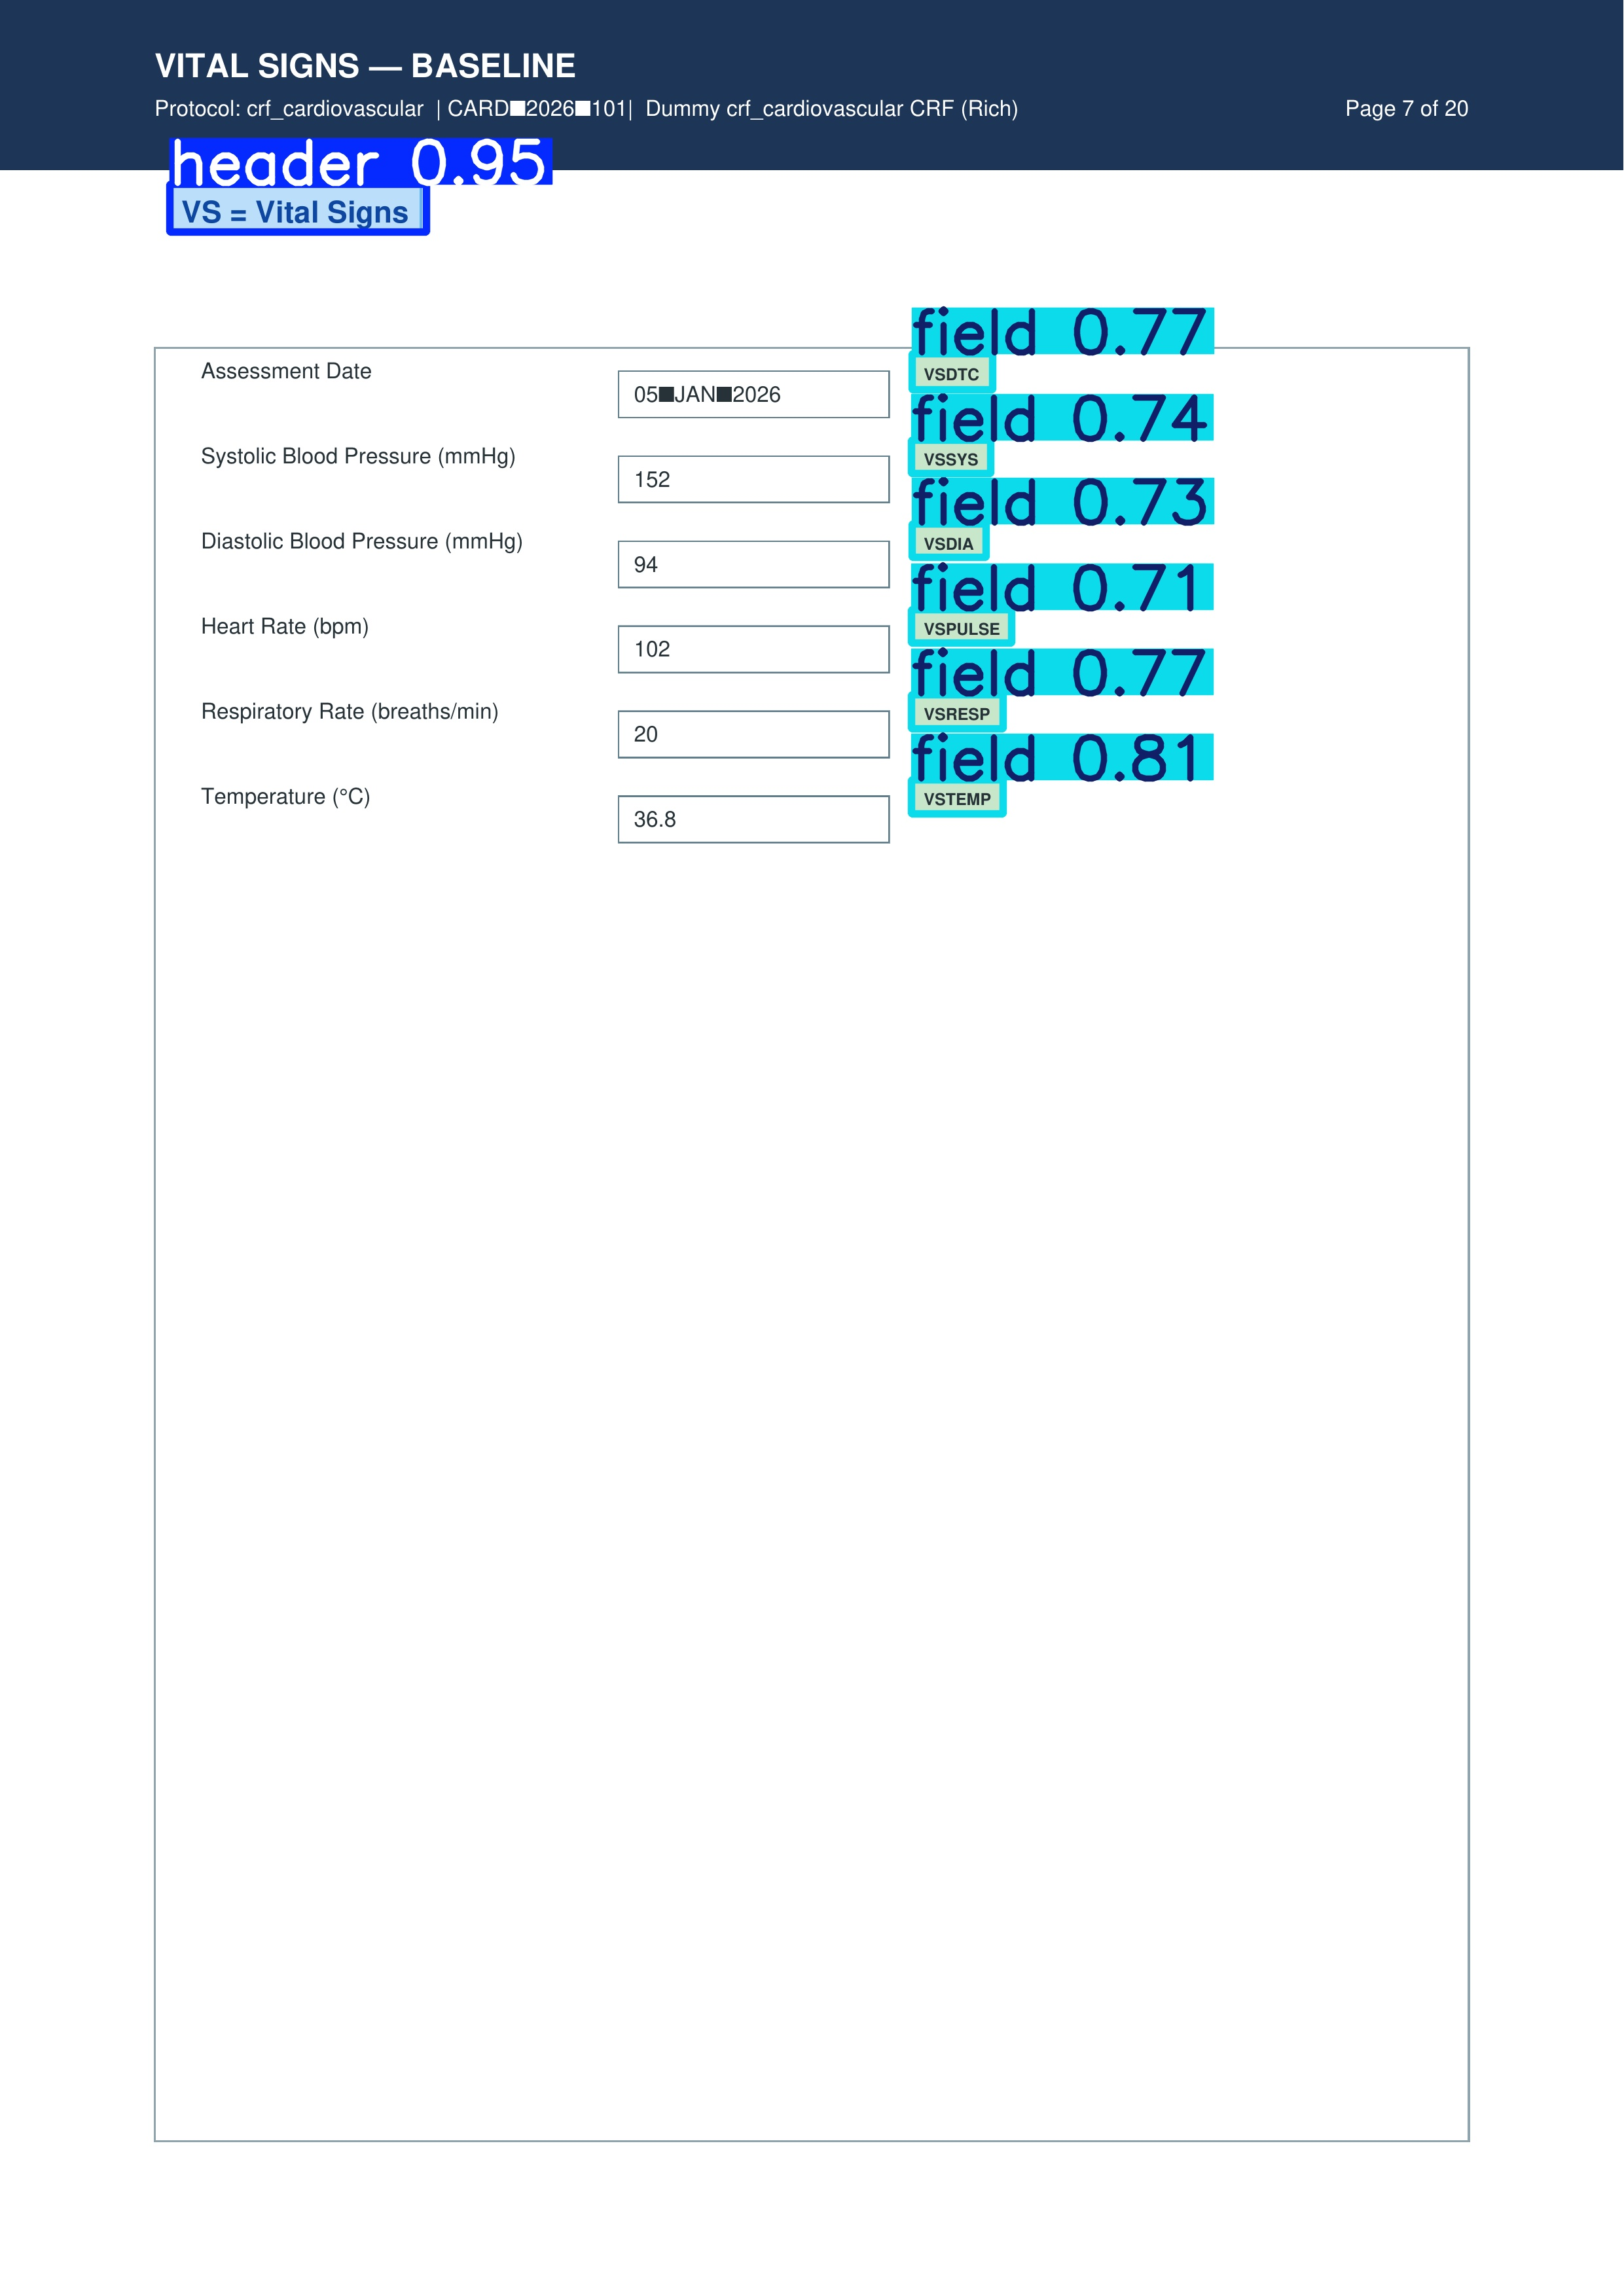


--- Detections ---
Class: header, Confidence: 0.95, Bounding Box: [259.63482666015625, 281.1808166503906, 651.3770751953125, 354.6050109863281]
Class: field, Confidence: 0.81, Bounding Box: [1392.6551513671875, 1191.4129638671875, 1532.46142578125, 1243.2239990234375]
Class: field, Confidence: 0.77, Bounding Box: [1392.01025390625, 1061.189697265625, 1532.1466064453125, 1113.1614990234375]
Class: field, Confidence: 0.77, Bounding Box: [1393.017333984375, 540.99365234375, 1516.20068359375, 595.8611450195312]
Class: field, Confidence: 0.74, Bounding Box: [1392.831787109375, 672.3924560546875, 1513.9210205078125, 723.864501953125]
Class: field, Confidence: 0.73, Bounding Box: [1393.2791748046875, 800.546142578125, 1506.1307373046875, 851.110107421875]
Class: field, Confidence: 0.71, Bounding Box: [1392.2073974609375, 931.2508544921875, 1545.764892578125, 982.2139892578125]


In [13]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Define the path to the best weights from the training run
trained_model_path = '/content/runs/detect/train-8/weights/best.pt'

# Load the trained model
model = YOLO(trained_model_path)

print(f"Loaded model from: {trained_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Get a different sample image from the validation set (e.g., the second one alphabetically)
sample_image_name = sorted(os.listdir(val_images_dir))[1] # Pick the second image alphabetically
sample_image_path = os.path.join(val_images_dir, sample_image_name)

print(f"Running inference on sample image: {sample_image_path}")

# Run inference
# The 'save=True' argument will save the image with predictions overlaid
results = model.predict(source=sample_image_path, save=True, imgsz=1024, conf=0.5, name='predict_sample_2')

# Ultralytics often saves results as .jpg even if input was .png
output_image_path = os.path.join(results[0].save_dir, os.path.splitext(sample_image_name)[0] + '.jpg')

if os.path.exists(output_image_path):
    print(f"\n--- Inference Results on {sample_image_name} ---")
    display(Image(filename=output_image_path))
else:
    print(f"Predicted image not found at: {output_image_path}")

# Optional: Print detected bounding boxes and classes
print("\n--- Detections ---")
for r in results:
    for box in r.boxes:
        c = int(box.cls)
        conf = box.conf.item()
        xyxy = box.xyxy[0].tolist() # [x1, y1, x2, y2]
        print(f"Class: {model.names[c]}, Confidence: {conf:.2f}, Bounding Box: {xyxy}")

### Run Inference on a Second New Image

Let's run inference on another image from the validation set to further test our trained model.

Loaded model from: /content/runs/detect/train-8/weights/best.pt
Running inference on sample image: /content/crf-dataset-fresh/crf_val/images/crf_glaucoma_page_007.png

image 1/1 /content/crf-dataset-fresh/crf_val/images/crf_glaucoma_page_007.png: 1024x736 1 header, 6 fields, 11.8ms
Speed: 6.1ms preprocess, 11.8ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 736)
Results saved to /content/runs/detect/predict_sample_3

--- Inference Results on crf_glaucoma_page_007.png ---


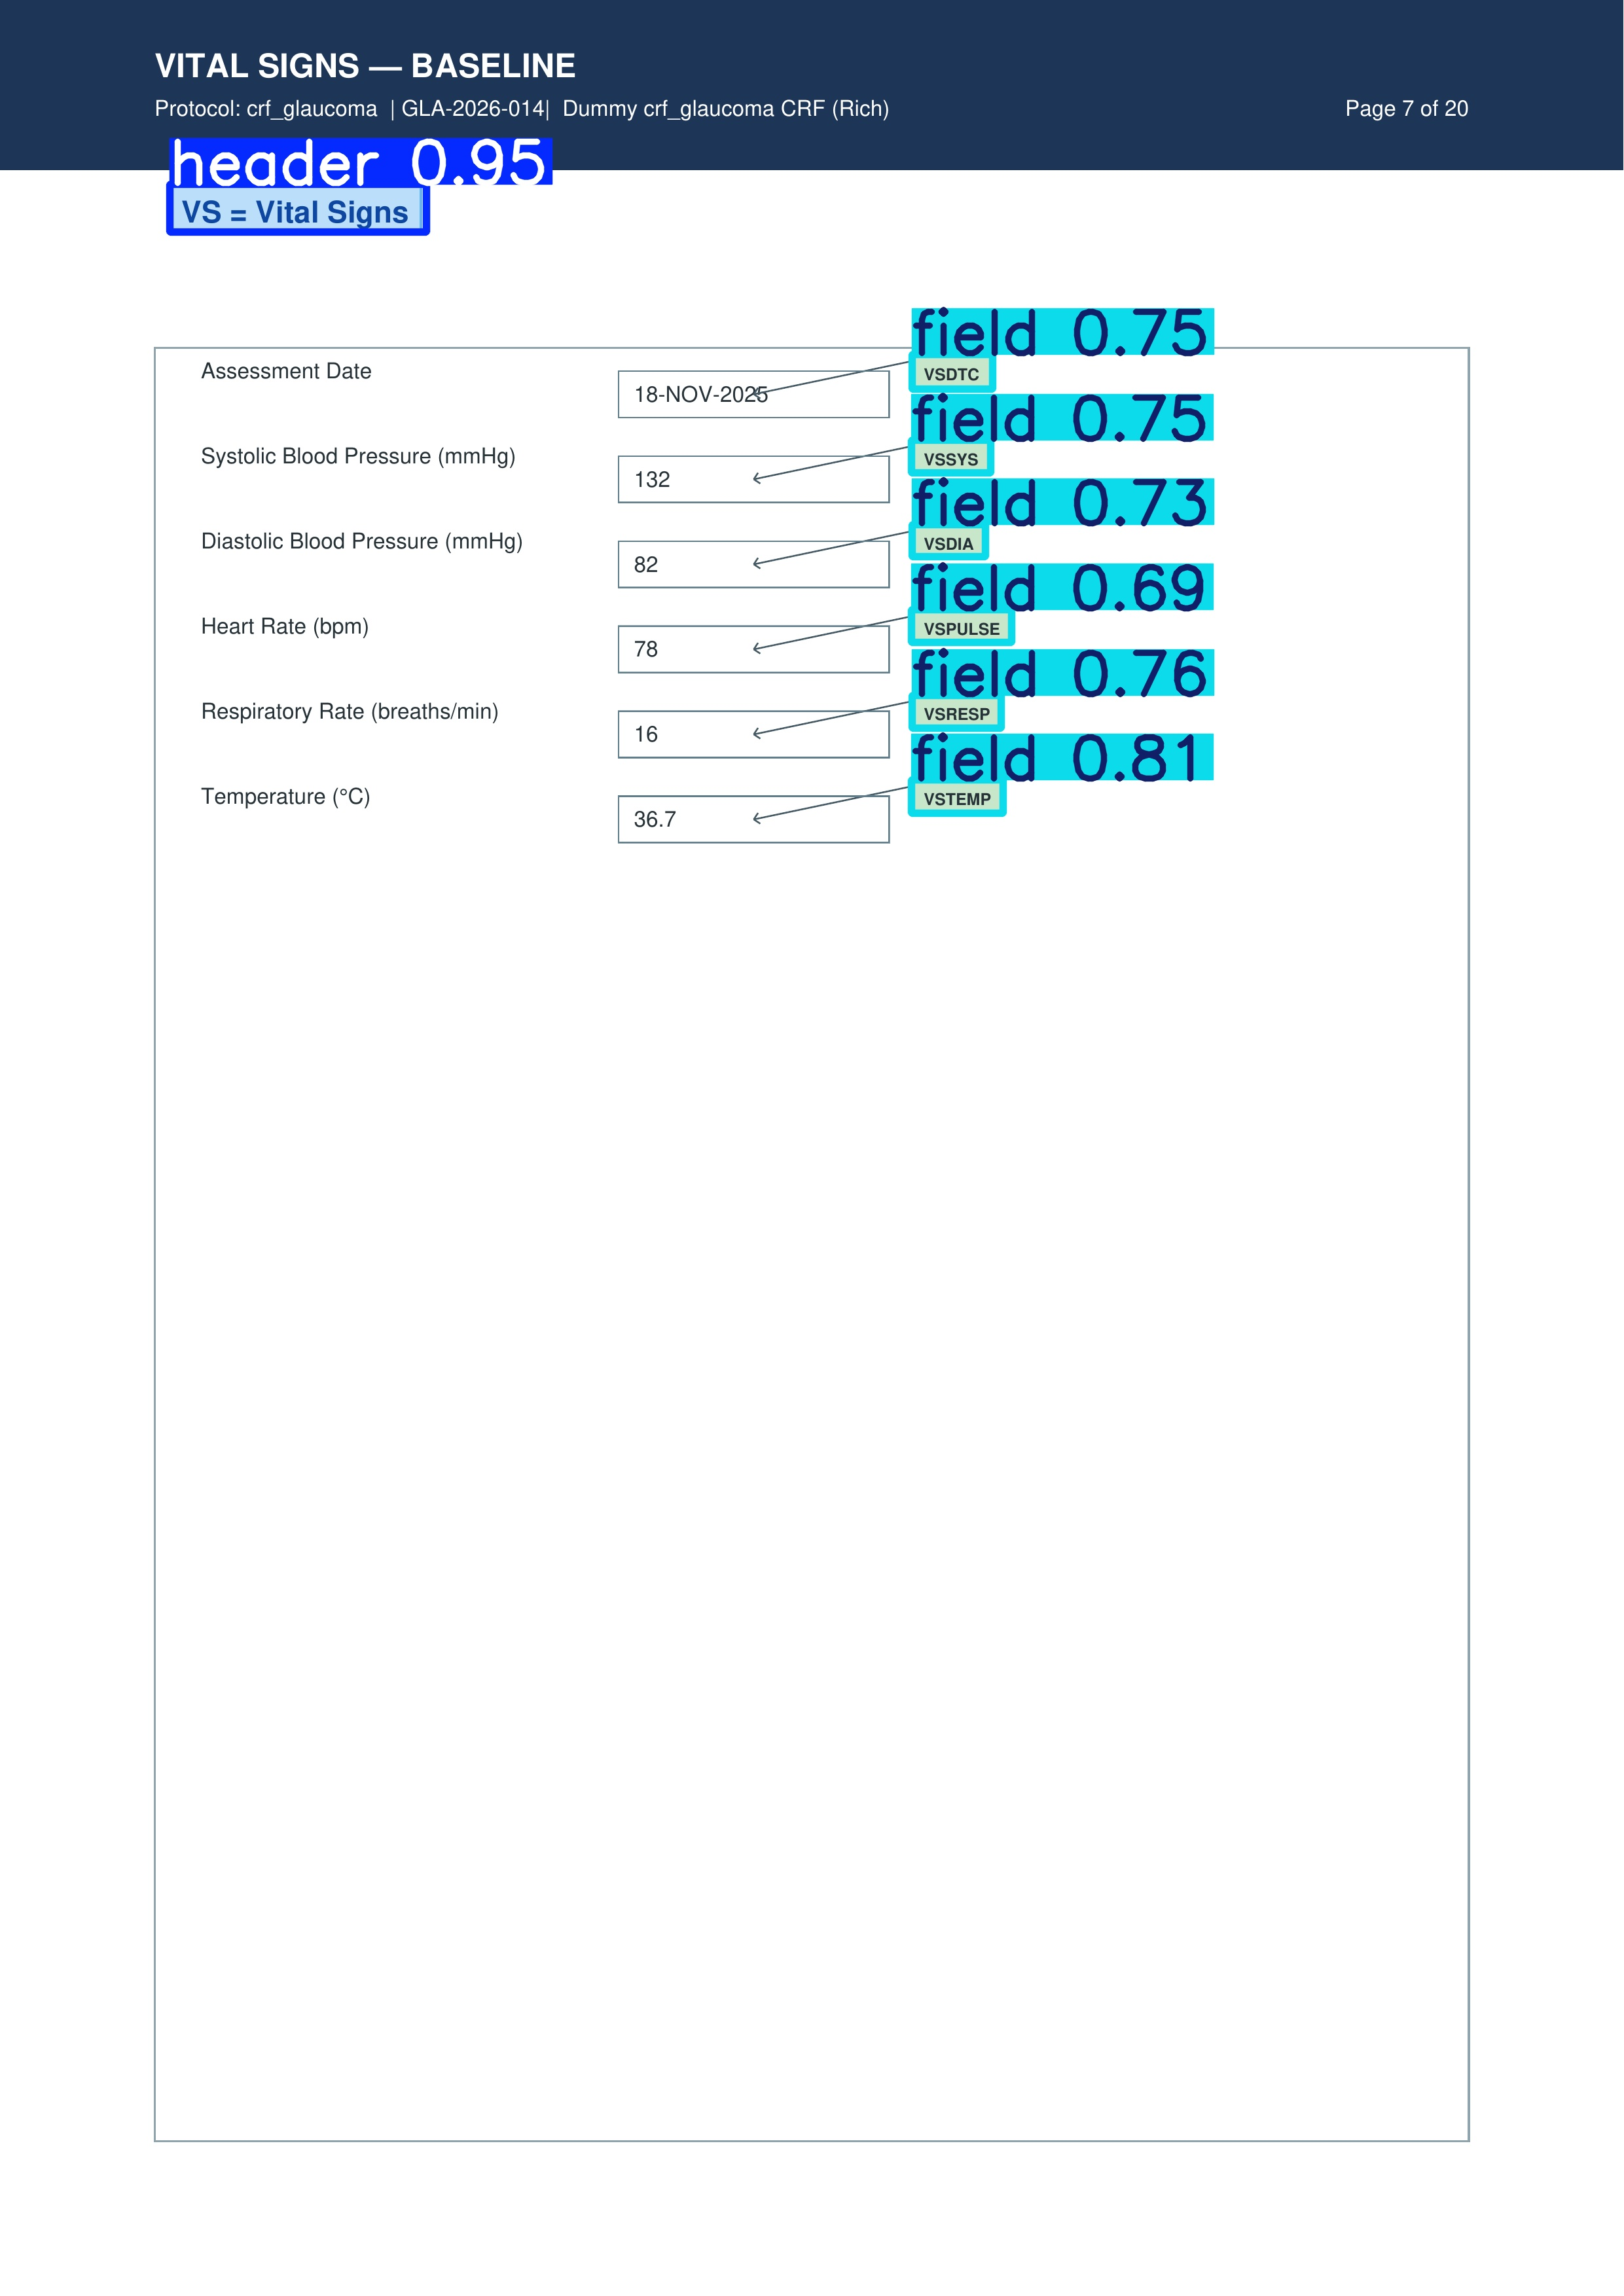


--- Detections ---
Class: header, Confidence: 0.95, Bounding Box: [259.62554931640625, 281.1317138671875, 651.958984375, 354.63934326171875]
Class: field, Confidence: 0.81, Bounding Box: [1392.59423828125, 1191.656005859375, 1532.237548828125, 1242.760009765625]
Class: field, Confidence: 0.76, Bounding Box: [1393.337890625, 1062.00341796875, 1529.546875, 1112.8114013671875]
Class: field, Confidence: 0.75, Bounding Box: [1393.326904296875, 541.4727172851562, 1516.1185302734375, 594.8770751953125]
Class: field, Confidence: 0.75, Bounding Box: [1392.94970703125, 672.6708984375, 1513.920654296875, 722.923583984375]
Class: field, Confidence: 0.73, Bounding Box: [1393.904541015625, 801.5155029296875, 1505.7586669921875, 850.447265625]
Class: field, Confidence: 0.69, Bounding Box: [1392.061279296875, 931.3685913085938, 1545.8154296875, 981.7156982421875]


In [14]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Define the path to the best weights from the training run
trained_model_path = '/content/runs/detect/train-8/weights/best.pt'

# Load the trained model
model = YOLO(trained_model_path)

print(f"Loaded model from: {trained_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Get a different sample image from the validation set (e.g., the third one alphabetically)
sorted_val_images = sorted(os.listdir(val_images_dir))

# Ensure there are enough images to pick the third one
if len(sorted_val_images) >= 3:
    sample_image_name = sorted_val_images[2] # Pick the third image alphabetically
else:
    print("Warning: Not enough images in validation set to pick the third one. Picking the first available.")
    sample_image_name = sorted_val_images[0]

sample_image_path = os.path.join(val_images_dir, sample_image_name)

print(f"Running inference on sample image: {sample_image_path}")

# Run inference
# The 'save=True' argument will save the image with predictions overlaid
# Use a new name for the prediction run to avoid overwriting previous results
results = model.predict(source=sample_image_path, save=True, imgsz=1024, conf=0.5, name='predict_sample_3')

# Ultralytics often saves results as .jpg even if input was .png
output_image_path = os.path.join(results[0].save_dir, os.path.splitext(sample_image_name)[0] + '.jpg')

if os.path.exists(output_image_path):
    print(f"\n--- Inference Results on {sample_image_name} ---")
    display(Image(filename=output_image_path))
else:
    print(f"Predicted image not found at: {output_image_path}")

# Optional: Print detected bounding boxes and classes
print("\n--- Detections ---")
for r in results:
    for box in r.boxes:
        c = int(box.cls)
        conf = box.conf.item()
        xyxy = box.xyxy[0].tolist() # [x1, y1, x2, y2]
        print(f"Class: {model.names[c]}, Confidence: {conf:.2f}, Bounding Box: {xyxy}")

### Exporting the Trained Model

Now that we have a trained and tested model, let's export it to a common deployment format like ONNX. This allows for easier integration into various applications and environments.

In [15]:
from ultralytics import YOLO
import os

# Define the path to the best weights from the training run
trained_model_path = '/content/runs/detect/train-8/weights/best.pt'

# Load the trained model
model = YOLO(trained_model_path)

print(f"Loaded model from: {trained_model_path}")

# Export the model to ONNX format
# You can change the 'format' argument to 'tflite', 'torchscript', 'openvino', 'coreml', etc.
exported_model_path = model.export(format='onnx')

print(f"Model successfully exported to: {exported_model_path}")

# Verify the exported file exists
if os.path.exists(exported_model_path):
    print(f"Exported model file found at: {exported_model_path}")
    print(f"File size: {os.path.getsize(exported_model_path) / (1024*1024):.2f} MB")
else:
    print(f"Error: Exported model file not found at: {exported_model_path}")

Loaded model from: /content/runs/detect/train-8/weights/best.pt
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train-8/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 6, 21504) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 293ms
Prepared 4 packages in 7.80s
Installed 4 packages in 285ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 8.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take eff

### Exporting to TensorRT for Jetson J40

For deployment on NVIDIA Jetson devices like the J40, converting the model to **TensorRT** format is crucial for optimal performance. TensorRT is NVIDIA's platform for high-performance deep learning inference, which can significantly accelerate inference speed and reduce memory footprint by optimizing the model graph for NVIDIA GPUs.

In [16]:
from ultralytics import YOLO
import os

# Define the path to the best weights from the training run
trained_model_path = '/content/runs/detect/train-8/weights/best.pt'

# Load the trained model
model = YOLO(trained_model_path)

print(f"Loaded model from: {trained_model_path}")

# Export the model to TensorRT format (.engine file)
# The 'engine' format in Ultralytics automatically handles TensorRT conversion.
print("\nExporting model to TensorRT format...")
trt_model_path = model.export(format='engine', imgsz=1024, half=True) # half=True for FP16 precision

print(f"Model successfully exported to TensorRT at: {trt_model_path}")

# Verify the exported file exists
if os.path.exists(trt_model_path):
    print(f"Exported TensorRT model file found at: {trt_model_path}")
    print(f"File size: {os.path.getsize(trt_model_path) / (1024*1024):.2f} MB")
else:
    print(f"Error: Exported TensorRT model file not found at: {trt_model_path}")

Loaded model from: /content/runs/detect/train-8/weights/best.pt

Exporting model to TensorRT format...
WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train-8/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 6, 21504) (6.0 MB)

ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 1.0s, saved as '/content/runs/detect/train-8/weights/best.onnx' (11.9 MB)
requirements: Ultralytics requirement ['tensorrt-cu12>=7.0.0,!=10.2.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 3 packages in 1m 16s
Prepared 3 packages in 1m 54s
Installed 3 packages in 2ms
 + tensorrt-cu12==10.16.1.11
 + tensorrt-cu12-bindings==10.16.1.11
 + tensorrt-

### Verify TensorRT Export with Inference

Now that the model is exported to TensorRT format, let's load it and run inference on a sample image to ensure it works correctly and produces expected detections.

Loaded TensorRT model from: /content/runs/detect/train-8/weights/best.engine
Running inference with TensorRT model on sample image: /content/crf-dataset-fresh/crf_val/images/crf_image_12.png
Loading /content/runs/detect/train-8/weights/best.engine for TensorRT inference...

image 1/1 /content/crf-dataset-fresh/crf_val/images/crf_image_12.png: 1024x1024 1 field, 5.2ms
Speed: 5.4ms preprocess, 5.2ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/detect/predict_with_trt

--- Inference Results with TensorRT on crf_image_12.png ---


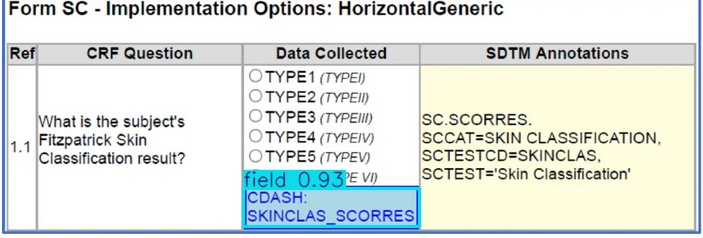


--- Detections (TensorRT) ---
Class: field, Confidence: 0.93, Bounding Box: [243.029296875, 188.7939453125, 419.12255859375, 226.552734375]


In [17]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Path to the exported TensorRT model
tensorrt_model_path = '/content/runs/detect/train-8/weights/best.engine'

# Load the TensorRT model (YOLO can directly load .engine files)
# Note: When loading an .engine model, it's already optimized, and you might not need to specify imgsz or half again for inference, but including them for clarity.
model_trt = YOLO(tensorrt_model_path)

print(f"Loaded TensorRT model from: {tensorrt_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Get a sample image from the validation set. We'll pick the fourth one to avoid duplicates.
sorted_val_images = sorted(os.listdir(val_images_dir))

# Ensure there are enough images to pick the fourth one
if len(sorted_val_images) >= 4:
    sample_image_name_trt = sorted_val_images[3] # Pick the fourth image alphabetically
else:
    print("Warning: Not enough images in validation set to pick the fourth one. Picking the first available.")
    sample_image_name_trt = sorted_val_images[0]

sample_image_path_trt = os.path.join(val_images_dir, sample_image_name_trt)

print(f"Running inference with TensorRT model on sample image: {sample_image_path_trt}")

# Run inference using the TensorRT model
# The 'save=True' argument will save the image with predictions overlaid
# Use a new name for the prediction run to avoid overwriting previous results
results_trt = model_trt.predict(source=sample_image_path_trt, save=True, imgsz=1024, conf=0.5, name='predict_with_trt', half=True)

# Ultralytics often saves results as .jpg even if input was .png
output_image_path_trt = os.path.join(results_trt[0].save_dir, os.path.splitext(sample_image_name_trt)[0] + '.jpg')

if os.path.exists(output_image_path_trt):
    print(f"\n--- Inference Results with TensorRT on {sample_image_name_trt} ---")
    display(Image(filename=output_image_path_trt))
else:
    print(f"Predicted image not found at: {output_image_path_trt}")

# Optional: Print detected bounding boxes and classes
print("\n--- Detections (TensorRT) ---")
for r in results_trt:
    for box in r.boxes:
        c = int(box.cls)
        conf = box.conf.item()
        xyxy = box.xyxy[0].tolist() # [x1, y1, x2, y2]
        print(f"Class: {model_trt.names[c]}, Confidence: {conf:.2f}, Bounding Box: {xyxy}")

### Inference on `crf_image_15.png` with TensorRT Model

Let's perform another inference run using the TensorRT optimized model on a different image (`crf_image_15.png`) from the validation set.

Loaded TensorRT model from: /content/runs/detect/train-8/weights/best.engine
Running inference with TensorRT model on sample image: /content/crf-dataset-fresh/crf_val/images/crf_image_15.png
Loading /content/runs/detect/train-8/weights/best.engine for TensorRT inference...

image 1/1 /content/crf-dataset-fresh/crf_val/images/crf_image_15.png: 1024x1024 4 headers, 21 fields, 5.2ms
Speed: 5.3ms preprocess, 5.2ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/detect/predict_with_trt_image_15

--- Inference Results with TensorRT on crf_image_15.png ---


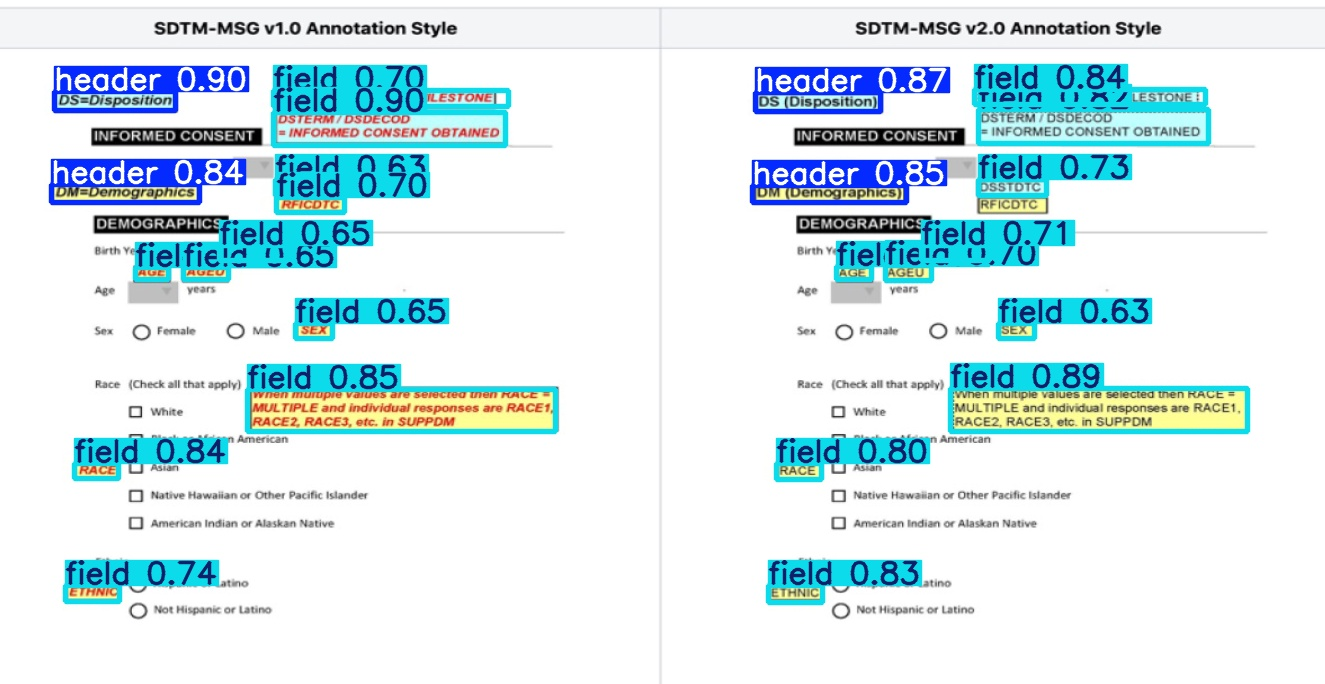


--- Detections (TensorRT) ---
Class: field, Confidence: 0.90, Bounding Box: [273.10333251953125, 112.249755859375, 505.20477294921875, 145.245361328125]
Class: header, Confidence: 0.90, Bounding Box: [54.1839599609375, 91.3848876953125, 175.9765625, 110.4705810546875]
Class: field, Confidence: 0.89, Bounding Box: [950.079345703125, 388.507080078125, 1247.039794921875, 431.854248046875]
Class: header, Confidence: 0.87, Bounding Box: [755.01708984375, 92.840576171875, 880.52978515625, 111.602783203125]
Class: header, Confidence: 0.85, Bounding Box: [752.752685546875, 185.1959228515625, 906.085205078125, 202.9876708984375]
Class: field, Confidence: 0.85, Bounding Box: [247.9522705078125, 389.154052734375, 555.5877685546875, 431.207275390625]
Class: header, Confidence: 0.84, Bounding Box: [51.151275634765625, 184.2254638671875, 199.22714233398438, 202.6641845703125]
Class: field, Confidence: 0.84, Bounding Box: [74.8870849609375, 463.555908203125, 118.2342529296875, 478.436279296875]
Clas

In [18]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Path to the exported TensorRT model
tensorrt_model_path = '/content/runs/detect/train-8/weights/best.engine'

# Load the TensorRT model
model_trt = YOLO(tensorrt_model_path)

print(f"Loaded TensorRT model from: {tensorrt_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Specify the target image name
sample_image_name_trt_2 = 'crf_image_15.png'
sample_image_path_trt_2 = os.path.join(val_images_dir, sample_image_name_trt_2)

print(f"Running inference with TensorRT model on sample image: {sample_image_path_trt_2}")

# Run inference using the TensorRT model
# Use a new name for the prediction run to avoid overwriting previous results
results_trt_2 = model_trt.predict(source=sample_image_path_trt_2, save=True, imgsz=1024, conf=0.5, name='predict_with_trt_image_15', half=True)

# Ultralytics often saves results as .jpg even if input was .png
output_image_path_trt_2 = os.path.join(results_trt_2[0].save_dir, os.path.splitext(sample_image_name_trt_2)[0] + '.jpg')

if os.path.exists(output_image_path_trt_2):
    print(f"\n--- Inference Results with TensorRT on {sample_image_name_trt_2} ---")
    display(Image(filename=output_image_path_trt_2))
else:
    print(f"Predicted image not found at: {output_image_path_trt_2}")

# Optional: Print detected bounding boxes and classes
print("\n--- Detections (TensorRT) ---")
for r in results_trt_2:
    for box in r.boxes:
        c = int(box.cls)
        conf = box.conf.item()
        xyxy = box.xyxy[0].tolist()
        print(f"Class: {model_trt.names[c]}, Confidence: {conf:.2f}, Bounding Box: {xyxy}")

### Calculate Average Inference Time

To get a more representative measure of the TensorRT model's performance, let's calculate the average inference time over a larger set of validation images. This will involve running inference on multiple images and then averaging the reported inference speeds.

In [20]:
from ultralytics import YOLO
import os
import time

# Path to the exported TensorRT model
tensorrt_model_path = '/content/runs/detect/train-8/weights/best.engine'

# Load the TensorRT model once
model_trt = YOLO(tensorrt_model_path)
print(f"Loaded TensorRT model from: {tensorrt_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Get a list of all validation images
all_val_images = [f for f in os.listdir(val_images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Use all available validation images for average calculation
sample_images_for_avg = sorted(all_val_images)

if not sample_images_for_avg:
    print("No validation images found to calculate average inference time.")
else:
    inference_times_ms = []
    print(f"\nCalculating average inference time over {len(sample_images_for_avg)} images...")

    for i, image_name in enumerate(sample_images_for_avg):
        image_path = os.path.join(val_images_dir, image_name)
        print(f"  ({i+1}/{len(sample_images_for_avg)}) Inferring on: {image_name}")

        # Run inference and capture results
        # We don't need to save or display results for this calculation
        results = model_trt.predict(
            source=image_path,
            save=False, # Do not save predicted images
            imgsz=1024,
            conf=0.5,
            half=True,
            verbose=False # Suppress verbose output for each image
        )

        # Extract inference time from the results object
        # Ultralytics results objects contain speed information
        if results and hasattr(results[0], 'speed'):
            # Inference speed is usually reported in ms
            inference_time_ms = results[0].speed['inference']
            inference_times_ms.append(inference_time_ms)
            print(f"    Inference time for {image_name}: {inference_time_ms:.2f} ms")
        else:
            print(f"    Could not extract inference time for {image_name}")

    if inference_times_ms:
        average_inference_time_ms = sum(inference_times_ms) / len(inference_times_ms)
        print(f"\nAverage inference time across {len(inference_times_ms)} images: {average_inference_time_ms:.2f} ms")
    else:
        print("No inference times collected.")

Loaded TensorRT model from: /content/runs/detect/train-8/weights/best.engine

Calculating average inference time over 14 images...
  (1/14) Inferring on: crf_cardiovascular_page_002.png
Loading /content/runs/detect/train-8/weights/best.engine for TensorRT inference...
    Inference time for crf_cardiovascular_page_002.png: 5.19 ms
  (2/14) Inferring on: crf_cardiovascular_page_007.png
    Inference time for crf_cardiovascular_page_007.png: 5.18 ms
  (3/14) Inferring on: crf_glaucoma_page_007.png
    Inference time for crf_glaucoma_page_007.png: 5.18 ms
  (4/14) Inferring on: crf_image_12.png
    Inference time for crf_image_12.png: 5.19 ms
  (5/14) Inferring on: crf_image_13.png
    Inference time for crf_image_13.png: 5.14 ms
  (6/14) Inferring on: crf_image_15.png
    Inference time for crf_image_15.png: 5.12 ms
  (7/14) Inferring on: crf_image_2.png
    Inference time for crf_image_2.png: 5.16 ms
  (8/14) Inferring on: crf_image_3.png
    Inference time for crf_image_3.png: 5.15 ms


In [21]:
import pandas as pd
import os

# Ensure inference_times_ms and sample_images_for_avg are available
# (These variables are generated by the previous cell '931e3779')
if 'inference_times_ms' in locals() and 'sample_images_for_avg' in locals():
    if inference_times_ms and sample_images_for_avg:
        # Create a DataFrame from the inference results
        inference_summary_df = pd.DataFrame({
            'Image Name': sample_images_for_avg,
            'Inference Time (ms)': inference_times_ms
        })

        # Add the overall average inference time for reference
        overall_avg_inference_time = sum(inference_times_ms) / len(inference_times_ms)
        inference_summary_df['Overall Average (ms)'] = overall_avg_inference_time

        # Define the path for the output CSV file
        output_csv_path = '/content/tensorrt_inference_summary.csv'

        # Save the DataFrame to a CSV file
        inference_summary_df.to_csv(output_csv_path, index=False)

        print(f"Inference summary saved to: {output_csv_path}")
        display(inference_summary_df.head())
    else:
        print("No inference data available to save to CSV.")
else:
    print("Error: 'inference_times_ms' or 'sample_images_for_avg' not found. Please run the previous cell first.")

Inference summary saved to: /content/tensorrt_inference_summary.csv


,Image Name,Inference Time (ms),Overall Average (ms)
0,crf_cardiovascular_page_002.png,5.192050,5.165282
1,crf_cardiovascular_page_007.png,5.175557,5.165282
2,crf_glaucoma_page_007.png,5.181718,5.165282
3,crf_image_12.png,5.188097,5.165282
4,crf_image_13.png,5.136871,5.165282


In [23]:
import numpy as np

# Ensure inference_times_ms is available
if 'inference_times_ms' in locals() and inference_times_ms:
    std_dev_inference_time_ms = np.std(inference_times_ms)
    print(f"Standard deviation of inference times: {std_dev_inference_time_ms:.2f} ms")
else:
    print("No inference times data available to calculate standard deviation.")

Standard deviation of inference times: 0.03 ms


In [22]:
from google.colab import files

output_csv_path = '/content/tensorrt_inference_summary.csv'

if os.path.exists(output_csv_path):
    files.download(output_csv_path)
    print(f"Downloading {output_csv_path}...")
else:
    print(f"Error: CSV file not found at {output_csv_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files
import os

# Define the path to the best.engine file
engine_file_path = '/content/runs/detect/train-8/weights/best.engine'

if os.path.exists(engine_file_path):
    print(f"Downloading {engine_file_path}...")
    files.download(engine_file_path)
else:
    print(f"Error: The engine file was not found at {engine_file_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>